# 불량 탐지 및 SHAP 기반 공정 전이 위험 예측

1. 라이브러리 import 및 Colab/Google Drive 로드
2. `app/ml/datasets/process/` 전체 데이터셋 정제 및 전처리
3. Bosch, Ford, 열화상, 소성가공 데이터 기반 보조 모델/피처 학습
4. 후보 모델 4종(LightGBM, RandomForest, ExtraTrees, LogisticRegression) 교차검증/튜닝
5. 최종 후보별 성능 비교, Accuracy, False Positive Rate, Confusion Matrix
6. SHAP 기반 영향 공정 분석 및 공정 간 전이 위험 결과 생성
7. AI 모델 관리 항목과 모델/결과 파일 저장

> 현재 데이터에는 `BODY 불량 -> PAINT 불량` 같은 실제 전이 정답 라벨과 데이터셋 간 공통 제품 키가 없습니다. 따라서 이 노트북의 전이 예측은 별도 전이 라벨 학습이 아니라, `최종 불량 확률 + SHAP 영향 공정 + 보조 공정 위험 피처 + 공정 흐름 규칙` 기반 위험 확산 해석입니다.


In [1]:
# Colab 환경에서 필요한 패키지 설치
import importlib.util
import subprocess
import sys

def ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])

ensure_package("lightgbm")
ensure_package("shap")
ensure_package("joblib")


In [2]:
# CPU 병렬 사용
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
)

In [3]:
from __future__ import annotations

import gc
import json
import pickle
import re
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas", pd.__version__)
print("lightgbm", lgb.__version__)
print("shap", shap.__version__)


pandas 2.2.2
lightgbm 4.6.0
shap 0.52.0


## 1. Google Drive 및 로컬 데이터셋 경로 설정


In [4]:
# Drive 마운트
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Colab이 아니므로 Google Drive mount를 건너뜁니다.")

# 데이터 루트
PROJECT_ROOT = Path("/content/drive/MyDrive") if IN_COLAB else Path.cwd()
PROCESS_ROOT = PROJECT_ROOT / "aims_dataset"
BOSCH_ROOT = PROCESS_ROOT / "bosch-production-line-performance"
THERMAL_ROOT = PROCESS_ROOT / "머신비전 AI 데이터셋 (열화상 기반 품질 검사 데이터)"
FORD_ROOT = PROCESS_ROOT / "Ford 엔진 진동 데이터셋"
METAL_ROOT = PROCESS_ROOT / "소성가공 자원최적화 AI 데이터셋"
# 산출물 경로
OUTPUT_DIR = Path("/content/defect_transfer_outputs") if IN_COLAB else Path("outputs/defect_transfer")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bosch 파일 경로
NUMERIC_PATH = BOSCH_ROOT / "train_numeric.csv"
DATE_PATH = BOSCH_ROOT / "train_date.csv"
CATEGORICAL_PATH = BOSCH_ROOT / "train_categorical.csv"

# 열화상 파일 경로
THERMAL_LEFT_DATA_PATH = THERMAL_ROOT / "2nd_process_left_data.csv"
THERMAL_LEFT_LABEL_PATH = THERMAL_ROOT / "2nd_process_left_label.json"
THERMAL_RIGHT_DATA_PATH = THERMAL_ROOT / "2nd_process_right_data.csv"
THERMAL_RIGHT_LABEL_PATH = THERMAL_ROOT / "2nd_process_right_label.json"

# 보조 데이터 파일 경로
FORD_TRAIN_PATH = FORD_ROOT / "FordA_TRAIN.txt"
FORD_TEST_PATH = FORD_ROOT / "FordA_TEST.txt"
METAL_PROCESS_PATH = METAL_ROOT / "공정_데이터_2022년_8월.csv"
METAL_SENSOR_PATHS = sorted([p for p in METAL_ROOT.glob("*.csv") if p.name != "공정_데이터_2022년_8월.csv"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESS_ROOT:", PROCESS_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive
PROCESS_ROOT: /content/drive/MyDrive/aims_dataset
OUTPUT_DIR: /content/defect_transfer_outputs


## 2. 대용량 CSV 로드 전략

Bosch 데이터는 매우 크므로 전체 컬럼을 한 번에 읽지 않습니다. 먼저 일부 행만 프로파일링한 뒤 결측률이 낮고 변동이 있는 컬럼을 고르고, 선택 컬럼만 학습 크기만큼 로드합니다.


In [5]:
# 학습 규모 설정
PROFILE_ROWS = 50_000
MAX_ROWS = 300_000
MAX_NUMERIC_FEATURES = 260
MAX_DATE_FEATURES = 260
USE_CATEGORICAL = True
MAX_CATEGORICAL_FEATURES = 80
CATEGORICAL_PROFILE_ROWS = 20_000
MAX_AUX_ROWS = 200_000
ENABLE_HYPERPARAMETER_TUNING = True
CV_N_SPLITS = 3
# 빠른 비교 모드 기본값
# 4개 모델 전체 조합을 큰 데이터로 CV하면 수십~수백 회 학습이 발생해 Colab에서 오래 걸립니다.
# 후보 비교는 stratified sample로 수행하고, 필요 시 선택 모델만 전체 데이터로 재학습합니다.
CV_N_ITER = 2
CV_SAMPLE_SIZE = 15_000
FINAL_TRAIN_SAMPLE_SIZE = 80_000
RETRAIN_SELECTED_MODEL_ON_FULL_DATA = False

# 공정 매핑
LINE_TO_PROCESS = {
    "L0": "PRESS",
    "L1": "BODY",
    "L2": "ASSEMBLY",
    "L3": "PAINT",
}
PROCESS_FLOW = ["PRESS", "BODY", "PAINT", "ASSEMBLY"]
PROCESS_DISPLAY = {
    "PRESS": "프레스",
    "BODY": "차체",
    "PAINT": "도장",
    "ASSEMBLY": "의장",
    "FINAL_INSPECTION": "최종검사",
    "UNKNOWN": "미분류",
}

# 파일 검증
def assert_file(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path}")

# 메모리 축소
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if col == "Id":
            df[col] = pd.to_numeric(df[col], downcast="integer")
            continue
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

# 라인 추출
def get_line(column: str) -> str:
    match = re.match(r"^(L\d+)_", column)
    return match.group(1) if match else "UNKNOWN"

# 스테이션 추출
def get_station(column: str) -> str:
    match = re.match(r"^(L\d+)_S(\d+)_", column)
    return f"{match.group(1)}_S{match.group(2)}" if match else "UNKNOWN"

# 컬럼 선별
def select_columns_by_profile(
    path: Path,
    *,
    required_cols: list[str],
    max_features: int,
    profile_rows: int,
    min_non_null_ratio: float = 0.02,
) -> list[str]:
    assert_file(path)
    sample = pd.read_csv(path, nrows=profile_rows)
    candidates = [c for c in sample.columns if c not in required_cols]
    non_null_ratio = sample[candidates].notna().mean()
    nunique = sample[candidates].nunique(dropna=True)
    score = (non_null_ratio * np.log1p(nunique)).sort_values(ascending=False)
    selected = score[(non_null_ratio >= min_non_null_ratio) & (nunique > 1)].head(max_features).index.tolist()
    del sample
    gc.collect()
    return required_cols + selected

# 선택 컬럼 로드
def read_selected_csv(path: Path, usecols: list[str], max_rows: int | None) -> pd.DataFrame:
    df = pd.read_csv(path, usecols=usecols, nrows=max_rows)
    return reduce_mem_usage(df)


In [6]:
# Bosch numeric 컬럼 선별
numeric_cols = select_columns_by_profile(
    NUMERIC_PATH,
    required_cols=["Id", "Response"],
    max_features=MAX_NUMERIC_FEATURES,
    profile_rows=PROFILE_ROWS,
)
# Bosch date 컬럼 선별
date_cols = select_columns_by_profile(
    DATE_PATH,
    required_cols=["Id"],
    max_features=MAX_DATE_FEATURES,
    profile_rows=PROFILE_ROWS,
)

# Bosch 선택 데이터 로드
numeric_df = read_selected_csv(NUMERIC_PATH, numeric_cols, MAX_ROWS)
date_df = read_selected_csv(DATE_PATH, date_cols, MAX_ROWS)

# Bosch categorical 선택 로드
if USE_CATEGORICAL:
    categorical_cols = select_columns_by_profile(
        CATEGORICAL_PATH,
        required_cols=["Id"],
        max_features=MAX_CATEGORICAL_FEATURES,
        profile_rows=CATEGORICAL_PROFILE_ROWS,
    )
    categorical_df = pd.read_csv(CATEGORICAL_PATH, usecols=categorical_cols, nrows=MAX_ROWS)
else:
    categorical_df = None

print("numeric_df:", numeric_df.shape)
print("date_df:", date_df.shape)
print("categorical_df:", None if categorical_df is None else categorical_df.shape)
print("Response ratio:")
display(numeric_df["Response"].value_counts(normalize=True).rename("ratio").to_frame())


numeric_df: (300000, 262)
date_df: (300000, 261)
categorical_df: (300000, 10)
Response ratio:


,ratio
Response,
0,0.99435
1,0.00565


## 3. Bosch Feature Engineering

`L*_S*_F*` 수치 센서와 `L*_S*_D*` 시간 컬럼을 그대로 일부 사용하면서, 공정/스테이션 단위 집계 피처를 추가합니다.


In [7]:
# Date 피처 생성
def build_date_features(date_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = pd.DataFrame({"Id": date_df["Id"]})
    date_feature_cols = [c for c in date_df.columns if c != "Id"]
    date_values = date_df[date_feature_cols]

    feature_df["date_observed_count"] = date_values.notna().sum(axis=1)
    feature_df["date_missing_ratio"] = date_values.isna().mean(axis=1)
    feature_df["process_start_time"] = date_values.min(axis=1)
    feature_df["process_end_time"] = date_values.max(axis=1)
    feature_df["total_process_duration"] = feature_df["process_end_time"] - feature_df["process_start_time"]

    # 라인별 시간 집계
    for line in sorted({get_line(c) for c in date_feature_cols if get_line(c) != "UNKNOWN"}):
        cols = [c for c in date_feature_cols if get_line(c) == line]
        values = date_df[cols]
        feature_df[f"{line}_date_seen"] = values.notna().any(axis=1).astype("int8")
        feature_df[f"{line}_date_count"] = values.notna().sum(axis=1)
        feature_df[f"{line}_date_missing_ratio"] = values.isna().mean(axis=1)
        feature_df[f"{line}_duration"] = values.max(axis=1) - values.min(axis=1)

    # 스테이션별 시간 집계
    station_span_cols = []
    for station in sorted({get_station(c) for c in date_feature_cols if get_station(c) != "UNKNOWN"}):
        cols = [c for c in date_feature_cols if get_station(c) == station]
        values = date_df[cols]
        span_col = f"{station}_span"
        feature_df[f"{station}_seen"] = values.notna().any(axis=1).astype("int8")
        feature_df[span_col] = values.max(axis=1) - values.min(axis=1)
        feature_df[f"{station}_mean_time"] = values.mean(axis=1)
        station_span_cols.append(span_col)

    # 병목 후보 시간 집계
    if station_span_cols:
        spans = feature_df[station_span_cols]
        feature_df["max_station_span"] = spans.max(axis=1)
        feature_df["mean_station_span"] = spans.mean(axis=1)
        feature_df["std_station_span"] = spans.std(axis=1)
        feature_df["active_station_count"] = feature_df[[c.replace("_span", "_seen") for c in station_span_cols]].sum(axis=1)
    return reduce_mem_usage(feature_df)

# Numeric 집계 피처 생성
def build_numeric_aggregate_features(numeric_df: pd.DataFrame) -> pd.DataFrame:
    value_cols = [c for c in numeric_df.columns if c not in ["Id", "Response"]]
    feature_df = numeric_df[["Id"]].copy()

    # 라인별 센서 집계
    for line in sorted({get_line(c) for c in value_cols if get_line(c) != "UNKNOWN"}):
        cols = [c for c in value_cols if get_line(c) == line]
        values = numeric_df[cols]
        feature_df[f"{line}_num_mean"] = values.mean(axis=1)
        feature_df[f"{line}_num_std"] = values.std(axis=1)
        feature_df[f"{line}_num_min"] = values.min(axis=1)
        feature_df[f"{line}_num_max"] = values.max(axis=1)
        feature_df[f"{line}_num_missing_ratio"] = values.isna().mean(axis=1)

    # 스테이션별 센서 집계
    for station in sorted({get_station(c) for c in value_cols if get_station(c) != "UNKNOWN"}):
        cols = [c for c in value_cols if get_station(c) == station]
        if len(cols) < 2:
            continue
        values = numeric_df[cols]
        feature_df[f"{station}_num_mean"] = values.mean(axis=1)
        feature_df[f"{station}_num_std"] = values.std(axis=1)
        feature_df[f"{station}_num_missing_ratio"] = values.isna().mean(axis=1)
    return reduce_mem_usage(feature_df)

# Categorical 피처 생성
def build_categorical_features(categorical_df: pd.DataFrame) -> pd.DataFrame:
    cat_cols = [c for c in categorical_df.columns if c != "Id"]
    feature_df = categorical_df[["Id"]].copy()
    if not cat_cols:
        return feature_df

    # 라인별 범주 집계
    for line in sorted({get_line(c) for c in cat_cols if get_line(c) != "UNKNOWN"}):
        cols = [c for c in cat_cols if get_line(c) == line]
        values = categorical_df[cols]
        feature_df[f"{line}_cat_count"] = values.notna().sum(axis=1)
        feature_df[f"{line}_cat_missing_ratio"] = values.isna().mean(axis=1)
        feature_df[f"{line}_cat_unique_count"] = values.nunique(axis=1, dropna=True)

    # 범주 인코딩
    for col in cat_cols:
        encoded, _ = pd.factorize(categorical_df[col].astype("string").fillna("__MISSING__"), sort=True)
        feature_df[f"{col}_code"] = encoded.astype("int32")
    return reduce_mem_usage(feature_df)

# Bosch 피처 생성
date_features = build_date_features(date_df)
numeric_agg_features = build_numeric_aggregate_features(numeric_df)
raw_numeric_features = numeric_df.drop(columns=["Response"])

# Bosch 피처 병합
features = raw_numeric_features.merge(date_features, on="Id", how="left")
features = features.merge(numeric_agg_features, on="Id", how="left")
if categorical_df is not None:
    categorical_features = build_categorical_features(categorical_df)
    features = features.merge(categorical_features, on="Id", how="left")
    del categorical_df, categorical_features
# 학습 라벨 분리
target = numeric_df[["Id", "Response"]].copy()

del date_df, numeric_agg_features, date_features
gc.collect()

print("features:", features.shape)
display(features.head())


features: (300000, 454)


,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,L0_S0_F20,L0_S0_F22,L0_S1_F24,L0_S1_F28,L0_S2_F36,L0_S2_F44,L0_S2_F48,L0_S2_F60,L0_S2_F64,L0_S3_F72,L0_S3_F80,L0_S3_F84,L0_S3_F96,L0_S3_F100,L0_S4_F104,L0_S4_F109,L0_S5_F114,L0_S5_F116,L0_S6_F122,L0_S6_F132,L0_S7_F138,L0_S7_F142,L0_S8_F144,L0_S8_F146,L0_S8_F149,L0_S9_F155,L0_S9_F160,L0_S9_F165,L0_S9_F170,L0_S9_F180,L0_S9_F185,L0_S9_F190,L0_S9_F195,L0_S9_F200,L0_S9_F210,L0_S10_F219,L0_S10_F224,L0_S10_F229,L0_S10_F234,L0_S10_F244,L0_S10_F249,L0_S10_F254,L0_S10_F259,L0_S10_F264,L0_S11_F282,L0_S11_F286,L0_S11_F290,L0_S11_F294,L0_S11_F302,...,L0_S5_num_mean,L0_S5_num_std,L0_S5_num_missing_ratio,L0_S6_num_mean,L0_S6_num_std,L0_S6_num_missing_ratio,L0_S7_num_mean,L0_S7_num_std,L0_S7_num_missing_ratio,L0_S8_num_mean,L0_S8_num_std,L0_S8_num_missing_ratio,L0_S9_num_mean,L0_S9_num_std,L0_S9_num_missing_ratio,L1_S24_num_mean,L1_S24_num_std,L1_S24_num_missing_ratio,L2_S26_num_mean,L2_S26_num_std,L2_S26_num_missing_ratio,L2_S27_num_mean,L2_S27_num_std,L2_S27_num_missing_ratio,L3_S29_num_mean,L3_S29_num_std,L3_S29_num_missing_ratio,L3_S30_num_mean,L3_S30_num_std,L3_S30_num_missing_ratio,L3_S33_num_mean,L3_S33_num_std,L3_S33_num_missing_ratio,L3_S34_num_mean,L3_S34_num_std,L3_S34_num_missing_ratio,L3_S35_num_mean,L3_S35_num_std,L3_S35_num_missing_ratio,L3_S36_num_mean,L3_S36_num_std,L3_S36_num_missing_ratio,L3_S37_num_mean,L3_S37_num_std,L3_S37_num_missing_ratio,L1_cat_count,L1_cat_missing_ratio,L1_cat_unique_count,L2_cat_count,L2_cat_missing_ratio,L2_cat_unique_count,L1_S24_F1114_code,L1_S24_F1137_code,L1_S24_F1140_code,L1_S24_F1510_code,L1_S24_F1525_code,L1_S24_F1530_code,L1_S25_F1852_code,L2_S26_F3099_code,L2_S27_F3192_code
0,4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,0.083,-0.273,-0.273,-0.271,0.167,-0.023,-0.088,0.001,-0.223,-0.030,NaN,NaN,NaN,NaN,NaN,-0.001,-0.004,NaN,NaN,NaN,NaN,-0.077,0.060,-0.157,0.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018,-0.136,-0.013,0.106,-0.131,...,NaN,NaN,1.0,NaN,NaN,1.0,-0.0085,0.096874,0.0,-0.052000,0.090934,0.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.014321,0.201176,0.0,0.003889,0.083444,0.37931,-0.0481,0.060306,0.0,0.0,0.0,0.0,-0.016143,0.030180,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0,1.0,0,0,1.0,0,5,4,4,5,5,5,8,2,2
1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.005264,0.142025,0.0,0.021621,0.068539,0.00000,-0.0370,0.063085,0.0,0.0,0.0,0.0,-0.001286,0.017289,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0,1.0,0,0,1.0,0,5,4,4,5,5,5,8,2,2
2,7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,-0.147,0.250,0.250,0.057,-0.079,0.011,-0.060,-0.005,-0.223,-0.077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.073,0.138,0.506,-0.13,NaN,NaN,-0.157,0.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002,-0.047,0.018,0.0,0.001,-0.009,-0.017,0.105,-0.001,NaN,NaN,NaN,NaN,NaN,...,0.0325,0.1492,0.0,0.188,0.44972,0.0,NaN,NaN,1.0,-0.052000,0.090934,0.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.010000,0.129113,0.0,-0.010552,0.069868,0.00000,0.1132,0.102470,0.0,0.0,0.0,0.0,-0.013857,0.039015,0.0,NaN,NaN,1.0,0.0,0.0,0.0,0,1.0,0,0,1.0,0,5,4,4,5,5,5,8,2,2
3,9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,-0.046,-0.253,-0.253,0.147,-0.007,0.120,-0.231,0.005,0.050,0.056,NaN,NaN,NaN,NaN,NaN,-0.038,-0.001,NaN,NaN,NaN,NaN,0.402,-0.015,0.343,0.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007,-0.049,0.020,0.0,-0.013,-0.003,-0.032,0.139,0.001,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,0.1935,0.294864,0.0,0.114667,0.197743,0.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,-0.030151,0.124692,0.0,0.010017,0.058393,0.00000,0.0282,0.049806,0.0,0.0,0.0,0.0,NaN,NaN,1.0,-0.05550,0.08526

## 4. Process 폴더 전체 보조 데이터 학습

`process` 폴더의 Bosch 외 데이터는 Bosch `Id`와 직접 연결되는 공통 키가 없습니다. 따라서 MVP에서는 각 데이터셋을 별도로 학습하여 공정별 보조 위험 신호를 만들고, Bosch 학습 테이블에는 반복 정렬(cyclic alignment) 방식으로 결합합니다. 운영 데이터에서 `car_master_id`, `event_time`, `process_code` 매핑이 생기면 이 부분을 정확 조인으로 교체하면 됩니다.


In [8]:
# 보조 피처 결합
def append_cycled_feature(target_df: pd.DataFrame, column: str, values: np.ndarray | pd.Series):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        print(f"{column}: 값이 없어 추가하지 않습니다.")
        return
    target_df[column] = np.resize(values, len(target_df))
    print(f"{column}: {len(values)}개 값을 {len(target_df)}개 Bosch row에 cyclic alignment로 추가")

# 보조 모델 평가
def evaluate_aux_classifier(name: str, y_true: pd.Series, proba: np.ndarray):
    pred = (proba >= 0.5).astype(int)
    print(f"\n== {name} auxiliary model ==")
    if y_true.nunique() > 1:
        print("ROC-AUC:", round(roc_auc_score(y_true, proba), 5))
        print("PR-AUC:", round(average_precision_score(y_true, proba), 5))
    print(classification_report(y_true, pred, digits=4))

# 보조 산출물 저장소
auxiliary_metrics = {}
auxiliary_models = {}

# 열화상 데이터 로드
def load_thermal_side(data_path: Path, label_path: Path, side: str) -> pd.DataFrame | None:
    if not data_path.exists() or not label_path.exists():
        return None
    data = pd.read_csv(data_path)
    data.columns = [f"t{i+1}" for i in range(data.shape[1])]
    with open(label_path, "r", encoding="utf-8") as f:
        labels = json.load(f)
    data = data.apply(pd.to_numeric, errors="coerce")
    out = pd.DataFrame({
        "thermal_side": side,
        "thermal_label": pd.Series(labels).astype(float).astype("int8"),
        "thermal_mean_temp": data.mean(axis=1),
        "thermal_std_temp": data.std(axis=1),
        "thermal_min_temp": data.min(axis=1),
        "thermal_max_temp": data.max(axis=1),
        "thermal_p90_temp": data.quantile(0.90, axis=1),
        "thermal_range_temp": data.max(axis=1) - data.min(axis=1),
        "thermal_slope": data.iloc[:, -1] - data.iloc[:, 0],
    })
    return reduce_mem_usage(out)

# 열화상 좌우 데이터 결합
thermal_frames = []
for item in [
    (THERMAL_LEFT_DATA_PATH, THERMAL_LEFT_LABEL_PATH, "left"),
    (THERMAL_RIGHT_DATA_PATH, THERMAL_RIGHT_LABEL_PATH, "right"),
]:
    thermal_side = load_thermal_side(*item)
    if thermal_side is not None:
        thermal_frames.append(thermal_side)

# 열화상 보조 모델 학습
if thermal_frames:
    thermal_df = pd.concat(thermal_frames, ignore_index=True)
    thermal_feature_cols = [c for c in thermal_df.columns if c.startswith("thermal_") and c not in ["thermal_side", "thermal_label"]]
    X_th = thermal_df[thermal_feature_cols]
    y_th = thermal_df["thermal_label"].astype(int)
    X_th_train, X_th_valid, y_th_train, y_th_valid = train_test_split(
        X_th, y_th, test_size=0.25, random_state=RANDOM_STATE, stratify=y_th if y_th.nunique() > 1 else None
    )
    thermal_model = lgb.LGBMClassifier(
        objective="binary", n_estimators=300, learning_rate=0.04, num_leaves=16,
        min_child_samples=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    # 열화상 불량 확률 학습
    thermal_model.fit(X_th_train, y_th_train)
    thermal_valid_proba = thermal_model.predict_proba(X_th_valid)[:, 1]
    evaluate_aux_classifier("Thermal PAINT quality", y_th_valid, thermal_valid_proba)
    thermal_all_proba = thermal_model.predict_proba(X_th)[:, 1]
    # 도장 보조 피처 추가
    append_cycled_feature(features, "aux_paint_thermal_defect_probability", thermal_all_proba)
    append_cycled_feature(features, "aux_paint_thermal_label", y_th)
    auxiliary_models["thermal_paint_quality"] = thermal_model
    auxiliary_metrics["thermal_rows"] = int(len(thermal_df))
    display(thermal_df.head())
else:
    thermal_df = None
    print("열화상 데이터 파일이 없어 열화상 보조 학습을 건너뜁니다.")


[LightGBM] [Info] Number of positive: 461, number of negative: 166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1349
[LightGBM] [Info] Number of data points in the train set: 627, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.735247 -> initscore=1.021410
[LightGBM] [Info] Start training from score 1.021410

== Thermal PAINT quality auxiliary model ==
ROC-AUC: 0.83824
PR-AUC: 0.91229
              precision    recall  f1-score   support

           0     0.5962    0.5636    0.5794        55
           1     0.8481    0.8645    0.8562       155

    accuracy                         0.7857       210
   macro avg     0.7221    0.7141    0.7178       210
weighted avg     0.7821    0.7857    0.7837       210

aux_paint_thermal_defect_probability: 837개 값을 300000개 Bosch row에 cyclic alignment로 추가
aux_paint_thermal_label:

,thermal_side,thermal_label,thermal_mean_temp,thermal_std_temp,thermal_min_temp,thermal_max_temp,thermal_p90_temp,thermal_range_temp,thermal_slope
0,left,0,51.042400,3.518454,42.534000,54.491001,54.271999,11.957,10.465
1,left,0,51.621162,2.787206,42.860001,54.021000,53.651199,11.161,9.378
2,left,0,51.391914,2.623878,43.202000,53.519001,53.315601,10.317,8.845
3,left,0,51.121414,3.284468,42.550999,53.926998,53.727699,11.376,9.862
4,left,0,50.737823,3.554459,42.051998,53.896000,53.601799,11.844,10.345


### 4.1 Ford 엔진 진동 데이터 보조 학습

FordA 데이터는 첫 번째 컬럼이 라벨입니다. `-1`을 이상/불량, `1`을 정상으로 변환해 PRESS/BODY 계열 설비 이상 확률을 학습합니다.


In [9]:
# Ford 진동 데이터 로드
def load_ford_txt(path: Path, max_rows: int | None = None) -> pd.DataFrame | None:
    if not path.exists():
        return None
    df = pd.read_csv(path, sep=r"\s+", header=None, nrows=max_rows)
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=0, how="any")
    df.columns = ["label"] + [f"ford_t{i}" for i in range(1, df.shape[1])]
    df["ford_abnormal_label"] = (df["label"] == -1).astype("int8")
    return reduce_mem_usage(df.drop(columns=["label"]))

# Ford train/test 로드
ford_train_df = load_ford_txt(FORD_TRAIN_PATH)
ford_test_df = load_ford_txt(FORD_TEST_PATH)

# Ford 보조 모델 학습
if ford_train_df is not None and ford_test_df is not None:
    ford_feature_cols = [c for c in ford_train_df.columns if c != "ford_abnormal_label"]
    X_ford_train = ford_train_df[ford_feature_cols]
    y_ford_train = ford_train_df["ford_abnormal_label"].astype(int)
    X_ford_test = ford_test_df[ford_feature_cols]
    y_ford_test = ford_test_df["ford_abnormal_label"].astype(int)

    ford_model = lgb.LGBMClassifier(
        objective="binary", n_estimators=500, learning_rate=0.03, num_leaves=31,
        min_child_samples=20, subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    # 진동 이상 확률 학습
    ford_model.fit(X_ford_train, y_ford_train)
    ford_test_proba = ford_model.predict_proba(X_ford_test)[:, 1]
    evaluate_aux_classifier("Ford PRESS/BODY vibration", y_ford_test, ford_test_proba)

    ford_all_df = pd.concat([ford_train_df, ford_test_df], ignore_index=True)
    ford_all_proba = ford_model.predict_proba(ford_all_df[ford_feature_cols])[:, 1]
    # 차체/프레스 보조 피처 추가
    append_cycled_feature(features, "aux_body_ford_vibration_abnormal_probability", ford_all_proba)
    append_cycled_feature(features, "aux_press_ford_vibration_abnormal_probability", ford_all_proba)
    auxiliary_models["ford_vibration"] = ford_model
    auxiliary_metrics["ford_rows"] = int(len(ford_all_df))
else:
    print("Ford 데이터 파일이 없어 Ford 보조 학습을 건너뜁니다.")


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 1
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 1, number of used features: 0
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[Li

### 4.2 소성가공 공정/전류 데이터 비지도 학습

소성가공 데이터에는 불량 라벨이 없으므로 공정 데이터와 설비 센서 데이터를 각각 Isolation Forest로 학습해 공정 흐름 이상 점수, 프레스 이상 점수, 로봇 전류 이상 점수를 생성합니다.


In [10]:
# Bosch numeric 컬럼 선별
numeric_cols = select_columns_by_profile(
    NUMERIC_PATH,
    required_cols=["Id", "Response"],
    max_features=MAX_NUMERIC_FEATURES,
    profile_rows=PROFILE_ROWS,
)
# Bosch date 컬럼 선별
date_cols = select_columns_by_profile(
    DATE_PATH,
    required_cols=["Id"],
    max_features=MAX_DATE_FEATURES,
    profile_rows=PROFILE_ROWS,
)

# Bosch 선택 데이터 로드
numeric_df = read_selected_csv(NUMERIC_PATH, numeric_cols, MAX_ROWS)
date_df = read_selected_csv(DATE_PATH, date_cols, MAX_ROWS)

# Bosch categorical 선택 로드
if USE_CATEGORICAL:
    categorical_cols = select_columns_by_profile(
        CATEGORICAL_PATH,
        required_cols=["Id"],
        max_features=MAX_CATEGORICAL_FEATURES,
        profile_rows=CATEGORICAL_PROFILE_ROWS,
    )
    categorical_df = pd.read_csv(CATEGORICAL_PATH, usecols=categorical_cols, nrows=MAX_ROWS)
else:
    categorical_df = None

print("numeric_df:", numeric_df.shape)
print("date_df:", date_df.shape)
print("categorical_df:", None if categorical_df is None else categorical_df.shape)
print("Response ratio:")
display(numeric_df["Response"].value_counts(normalize=True).rename("ratio").to_frame())


numeric_df: (300000, 262)
date_df: (300000, 261)
categorical_df: (300000, 10)
Response ratio:


,ratio
Response,
0,0.99435
1,0.00565


## 5. 학습 데이터 정제

4개 후보 모델이 동일한 학습 조건에서 비교될 수 있도록 무한대와 완전 결측 컬럼을 제거합니다. 불량 데이터는 희소하므로 stratified split과 class weight 기반 모델을 사용합니다.


In [11]:
# 학습 테이블 결합
model_df = features.merge(target, on="Id", how="inner")
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# 입력/라벨 분리
drop_cols = ["Id", "Response"]
feature_cols = [c for c in model_df.columns if c not in drop_cols]
# 완전 결측 컬럼 제거
all_missing_cols = model_df[feature_cols].columns[model_df[feature_cols].isna().all()].tolist()
if all_missing_cols:
    model_df = model_df.drop(columns=all_missing_cols)
    feature_cols = [c for c in feature_cols if c not in all_missing_cols]

X = model_df[feature_cols]
y = model_df["Response"].astype(int)
ids = model_df["Id"]
if y.nunique() < 2:
    raise ValueError("Response가 한 클래스만 포함되어 있습니다. MAX_ROWS를 늘리거나 데이터 샘플링 범위를 조정하세요.")

# 계층 분할
X_train, X_valid, y_train, y_valid, id_train, id_valid = train_test_split(
    X, y, ids,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 클래스 불균형 가중치
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("positive ratio train:", y_train.mean())
print("scale_pos_weight:", round(scale_pos_weight, 2))


X_train: (240000, 457) X_valid: (60000, 457)
positive ratio train: 0.00565
scale_pos_weight: 175.99


## 6. 전처리 학습 데이터셋 저장

모델에 실제로 들어가는 정제/전처리 완료 데이터셋을 파일로 저장합니다. Parquet 저장이 가능하면 `.parquet`, 환경에 `pyarrow/fastparquet`가 없으면 `.csv.gz`로 저장합니다.


In [12]:
# 학습 데이터셋 저장
def save_training_dataframe(df: pd.DataFrame, output_dir: Path, stem: str) -> Path:
    parquet_path = output_dir / f"{stem}.parquet"
    csv_path = output_dir / f"{stem}.csv.gz"
    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception as exc:
        print(f"Parquet 저장 실패, csv.gz로 저장합니다: {exc}")
        df.to_csv(csv_path, index=False, compression="gzip")
        return csv_path

# 전처리 결과 저장
training_dataset_path = save_training_dataframe(model_df, OUTPUT_DIR, "defect_transfer_training_dataset")

# 분할 ID 저장
split_ids = pd.DataFrame({
    "Id": pd.concat([id_train, id_valid]).astype(int).to_numpy(),
    "split": ["train"] * len(id_train) + ["valid"] * len(id_valid),
})
split_ids_path = OUTPUT_DIR / "defect_transfer_train_valid_split_ids.csv"
split_ids.to_csv(split_ids_path, index=False)

# 전처리 메타데이터
preprocessing_metadata = {
    "process_root": str(PROCESS_ROOT),
    "bosch_numeric_path": str(NUMERIC_PATH),
    "bosch_date_path": str(DATE_PATH),
    "bosch_categorical_path": str(CATEGORICAL_PATH),
    "use_categorical": bool(USE_CATEGORICAL),
    "profile_rows": int(PROFILE_ROWS),
    "max_rows": int(MAX_ROWS),
    "max_numeric_features": int(MAX_NUMERIC_FEATURES),
    "max_date_features": int(MAX_DATE_FEATURES),
    "max_categorical_features": int(MAX_CATEGORICAL_FEATURES),
    "selected_numeric_columns": numeric_cols,
    "selected_date_columns": date_cols,
    "selected_categorical_columns": categorical_cols if USE_CATEGORICAL else [],
    "dropped_all_missing_columns": all_missing_cols,
    "feature_columns": feature_cols,
    "target_column": "Response",
    "train_rows": int(len(X_train)),
    "valid_rows": int(len(X_valid)),
    "positive_ratio": float(y.mean()),
    "auxiliary_metrics": auxiliary_metrics,
    "created_at": datetime.now(timezone.utc).isoformat(),
}
preprocessing_metadata_path = OUTPUT_DIR / "defect_transfer_preprocessing_metadata.json"
preprocessing_metadata_path.write_text(json.dumps(preprocessing_metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("전처리 학습 데이터셋:", training_dataset_path)
print("train/valid split ids:", split_ids_path)
print("전처리 metadata:", preprocessing_metadata_path)


전처리 학습 데이터셋: /content/defect_transfer_outputs/defect_transfer_training_dataset.parquet
train/valid split ids: /content/defect_transfer_outputs/defect_transfer_train_valid_split_ids.csv
전처리 metadata: /content/defect_transfer_outputs/defect_transfer_preprocessing_metadata.json


## 7. 후보 모델 4종 교차검증 및 하이퍼파라미터 튜닝

불량 클래스가 희소하므로 모든 후보 모델은 같은 전처리/피처 엔지니어링 결과를 사용하고, `StratifiedKFold`로 클래스 비율을 유지하며 비교합니다.

후보 모델:

| 모델 | 목적 |
| --- | --- |
| LightGBM | 대용량 tabular 제조 데이터용 gradient boosting 기준 모델 |
| RandomForest | bagging 기반 tree ensemble 기준 모델 |
| ExtraTrees | 더 강한 randomization을 주는 tree ensemble 후보 |
| LogisticRegression | 선형 기준선 모델 |

비교 지표는 PR-AUC, ROC-AUC, Accuracy, False Positive Rate, F1을 함께 사용합니다.

`CV_SAMPLE_SIZE`, `CV_N_ITER`, `FINAL_TRAIN_SAMPLE_SIZE`는 실행 시간을 관리하는 핵심 설정입니다. 기본값은 빠른 비교 모드이며, 최종 제출/운영 모델이 필요할 때만 `RETRAIN_SELECTED_MODEL_ON_FULL_DATA=True`로 선택 모델 전체 재학습을 수행합니다.


In [13]:
# 평가 함수
def find_best_threshold(y_true: pd.Series, proba: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5
    f1_scores = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1_scores))])


def compute_binary_metrics(y_true: pd.Series, proba: np.ndarray, threshold: float) -> dict:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "false_positive_rate": float(fp / max(fp + tn, 1)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


def predict_positive_proba(estimator, X_input: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_input)[:, 1]
    decision = estimator.decision_function(X_input)
    return 1 / (1 + np.exp(-decision))


def make_candidate_models() -> dict:
    return {
        "LightGBM": {
            "estimator": lgb.LGBMClassifier(
                objective="binary",
                n_estimators=250,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight,
                verbosity=-1,
            ),
            "params": {
                "learning_rate": [0.03, 0.06],
                "num_leaves": [31, 63],
                "max_depth": [-1, 8],
                "min_child_samples": [80, 150],
                "subsample": [0.85, 1.0],
                "colsample_bytree": [0.85],
                "reg_lambda": [1.0, 2.0],
            },
            "selection_reason": "대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준 모델",
        },
        "RandomForest": {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(
                    n_estimators=120,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ]),
            "params": {
                "model__max_depth": [12, 20],
                "model__min_samples_leaf": [1, 5],
                "model__max_features": ["sqrt"],
            },
            "selection_reason": "bagging 기반 기준 모델로 과적합을 줄이고 안정적인 tree ensemble 성능 확인",
        },
        "ExtraTrees": {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", ExtraTreesClassifier(
                    n_estimators=160,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ]),
            "params": {
                "model__max_depth": [12, 20],
                "model__min_samples_leaf": [1, 5],
                "model__max_features": ["sqrt"],
            },
            "selection_reason": "RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교",
        },
        "LogisticRegression": {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                )),
            ]),
            "params": {
                "model__C": [0.1, 1.0],
                "model__solver": ["lbfgs"],
            },
            "selection_reason": "복잡한 tree 모델 대비 선형 기준선으로 feature engineering 자체의 설명력 확인",
        },
    }


# CV 데이터셋 규모 관리
if len(X_train) > CV_SAMPLE_SIZE:
    X_cv_pool, _, y_cv_pool, _ = train_test_split(
        X_train,
        y_train,
        train_size=CV_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_cv_pool = X_train
    y_cv_pool = y_train

effective_cv_splits = min(CV_N_SPLITS, int(y_cv_pool.value_counts().min()))
if effective_cv_splits < 2:
    raise ValueError("교차검증을 수행하기에 소수 클래스 샘플이 부족합니다. MAX_ROWS 또는 CV_SAMPLE_SIZE를 늘려주세요.")

candidate_configs = make_candidate_models()
skf = StratifiedKFold(n_splits=effective_cv_splits, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
best_params_by_model = {}

print(f"CV rows: {len(X_cv_pool):,} / train rows: {len(X_train):,}")
print(f"CV splits: {effective_cv_splits}, tuning trials per model: {CV_N_ITER if ENABLE_HYPERPARAMETER_TUNING else 1}")

# 후보 모델별 교차검증
for model_name, config in candidate_configs.items():
    param_candidates = list(ParameterSampler(
        config["params"],
        n_iter=CV_N_ITER,
        random_state=RANDOM_STATE,
    )) if ENABLE_HYPERPARAMETER_TUNING else [{}]

    print(f"\n[{model_name}] CV start - trials: {len(param_candidates)}")
    model_started_at = datetime.now()
    for trial_no, params in enumerate(param_candidates, start=1):
        fold_rows = []
        print(f"  trial {trial_no}/{len(param_candidates)} params={params}")
        for fold_no, (train_idx, valid_idx) in enumerate(skf.split(X_cv_pool, y_cv_pool), start=1):
            fold_started_at = datetime.now()
            X_fold_train = X_cv_pool.iloc[train_idx]
            y_fold_train = y_cv_pool.iloc[train_idx]
            X_fold_valid = X_cv_pool.iloc[valid_idx]
            y_fold_valid = y_cv_pool.iloc[valid_idx]

            cv_model = clone(config["estimator"])
            cv_model.set_params(**params)
            cv_model.fit(X_fold_train, y_fold_train)

            fold_proba = predict_positive_proba(cv_model, X_fold_valid)
            fold_threshold = find_best_threshold(y_fold_valid, fold_proba)
            fold_metrics = compute_binary_metrics(y_fold_valid, fold_proba, fold_threshold)
            fold_metrics.update({
                "model_name": model_name,
                "trial_no": trial_no,
                "fold_no": fold_no,
                "threshold": fold_threshold,
                **params,
            })
            fold_rows.append(fold_metrics)
            elapsed = (datetime.now() - fold_started_at).total_seconds()
            print(
                f"    fold {fold_no}/{effective_cv_splits} "
                f"PR-AUC={fold_metrics['pr_auc']:.5f} "
                f"F1={fold_metrics['f1']:.5f} "
                f"elapsed={elapsed:.1f}s"
            )

        fold_df = pd.DataFrame(fold_rows)
        row = {
            "model_name": model_name,
            "trial_no": trial_no,
            "mean_pr_auc": float(fold_df["pr_auc"].mean()),
            "std_pr_auc": float(fold_df["pr_auc"].std(ddof=0)),
            "mean_roc_auc": float(fold_df["roc_auc"].mean()),
            "std_roc_auc": float(fold_df["roc_auc"].std(ddof=0)),
            "mean_accuracy": float(fold_df["accuracy"].mean()),
            "mean_false_positive_rate": float(fold_df["false_positive_rate"].mean()),
            "mean_f1": float(fold_df["f1"].mean()),
            "mean_recall": float(fold_df["recall"].mean()),
            "params": params,
            "selection_reason": config["selection_reason"],
        }
        cv_rows.append(row)
        print(
            f"  -> {model_name} trial {trial_no} mean "
            f"PR-AUC={row['mean_pr_auc']:.5f} "
            f"ROC-AUC={row['mean_roc_auc']:.5f} "
            f"ACC={row['mean_accuracy']:.5f} "
            f"FPR={row['mean_false_positive_rate']:.5f}"
        )

    print(f"[{model_name}] CV done elapsed={(datetime.now() - model_started_at).total_seconds():.1f}s")

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["mean_pr_auc", "mean_roc_auc", "mean_f1", "mean_accuracy"],
    ascending=False,
).reset_index(drop=True)

for model_name in candidate_configs:
    best_params_by_model[model_name] = cv_results[cv_results["model_name"].eq(model_name)].iloc[0]["params"]

best_model_name = str(cv_results.iloc[0]["model_name"])
best_params = best_params_by_model[best_model_name]
best_model_selection_reason = str(cv_results.iloc[0]["selection_reason"])

cv_results_path = OUTPUT_DIR / "defect_model_cv_results.csv"
cv_results.to_csv(cv_results_path, index=False)

display(cv_results.head(20))
print("CV 결과 저장:", cv_results_path)
print("CV best model:", best_model_name, best_params)


CV rows: 15,000 / train rows: 240,000
CV splits: 3, tuning trials per model: 2

[LightGBM] CV start - trials: 2
  trial 1/2 params={'subsample': 0.85, 'reg_lambda': 1.0, 'num_leaves': 63, 'min_child_samples': 80, 'max_depth': 8, 'learning_rate': 0.06, 'colsample_bytree': 0.85}
    fold 1/3 PR-AUC=0.00869 F1=0.02994 elapsed=8.6s
    fold 2/3 PR-AUC=0.01054 F1=0.07317 elapsed=12.2s
    fold 3/3 PR-AUC=0.01394 F1=0.07059 elapsed=12.1s
  -> LightGBM trial 1 mean PR-AUC=0.01105 ROC-AUC=0.52870 ACC=0.96807 FPR=0.02715
  trial 2/2 params={'subsample': 0.85, 'reg_lambda': 2.0, 'num_leaves': 31, 'min_child_samples': 150, 'max_depth': 8, 'learning_rate': 0.06, 'colsample_bytree': 0.85}
    fold 1/3 PR-AUC=0.01117 F1=0.04878 elapsed=11.2s
    fold 2/3 PR-AUC=0.02039 F1=0.08333 elapsed=7.6s
    fold 3/3 PR-AUC=0.01637 F1=0.08955 elapsed=10.9s
  -> LightGBM trial 2 mean PR-AUC=0.01597 ROC-AUC=0.51714 ACC=0.98747 FPR=0.00744
[LightGBM] CV done elapsed=62.7s

[RandomForest] CV start - trials: 2
  tri

,model_name,trial_no,mean_pr_auc,std_pr_auc,mean_roc_auc,std_roc_auc,mean_accuracy,mean_false_positive_rate,mean_f1,mean_recall,params,selection_reason
0,ExtraTrees,2,0.021242,0.011941,0.591906,0.032715,0.979133,0.015822,0.069246,0.094417,"{'model__min_samples_leaf': 5, 'model__max_fea...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교
1,LogisticRegression,2,0.017179,0.012862,0.563373,0.026249,0.952933,0.042304,0.050928,0.118227,"{'model__solver': 'lbfgs', 'model__C': 1.0}",복잡한 tree 모델 대비 선형 기준선으로 feature engineering 자체...
2,LogisticRegression,1,0.016471,0.010389,0.568946,0.026550,0.976733,0.018303,0.053196,0.105911,"{'model__solver': 'lbfgs', 'model__C': 0.1}",복잡한 tree 모델 대비 선형 기준선으로 feature engineering 자체...
3,LightGBM,2,0.015974,0.003776,0.517136,0.027286,0.987467,0.007442,0.073889,0.094007,"{'subsample': 0.85, 'reg_lambda': 2.0, 'num_le...",대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준 모델
4,LightGBM,1,0.011054,0.002173,0.528703,0.050119,0.968067,0.027153,0.057900,0.129721,"{'subsample': 0.85, 'reg_lambda': 1.0, 'num_le...",대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준 모델
5,RandomForest,2,0.010481,0.001569,0.595697,0.021972,0.930467,0.065367,0.038165,0.201149,"{'model__min_samples_leaf': 5, 'model__max_fea...",bagging 기반 기준 모델로 과적합을 줄이고 안정적인 tree ensemble ...
6,RandomForest,1,0.010005,0.001341,0.603241,0.013798,0.913800,0.082060,0.037518,0.190066,"{'model__min_samples_leaf': 5, 'model__max_fea...",bagging 기반 기준 모델로 과적합을 줄이고 안정적인 tree ensemble ...
7,ExtraTrees,1,0.008998,0.001293,0.575575,0.010577,0.944333,0.051087,0.032750,0.142447,"{'model__min_samples_leaf': 5, 'model__max_fea...",RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교


CV 결과 저장: /content/defect_transfer_outputs/defect_model_cv_results.csv
CV best model: ExtraTrees {'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 20}


## 8. 후보 모델 4종 최종 학습 및 성능 비교

교차검증에서 선택된 모델별 best parameter로 4개 후보 모델을 모두 학습합니다.

각 모델은 같은 `X_train`, `X_valid`, `feature_cols`를 사용합니다.


In [14]:
trained_models = {}
model_valid_probabilities = {}
model_thresholds = {}
model_confusion_matrices = {}
model_eval_rows = []

# 최종 후보 비교용 학습 데이터셋 규모 관리
if len(X_train) > FINAL_TRAIN_SAMPLE_SIZE:
    X_final_train, _, y_final_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=FINAL_TRAIN_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )
else:
    X_final_train = X_train
    y_final_train = y_train

print(f"Final candidate training rows: {len(X_final_train):,} / train rows: {len(X_train):,}")

# 후보 모델 전체 학습
for model_name, config in candidate_configs.items():
    started_at = datetime.now()
    estimator = clone(config["estimator"])
    estimator.set_params(**best_params_by_model[model_name])
    print(f"[{model_name}] final fit start params={best_params_by_model[model_name]}")
    estimator.fit(X_final_train, y_final_train)

    proba = predict_positive_proba(estimator, X_valid)
    threshold = find_best_threshold(y_valid, proba)
    pred = (proba >= threshold).astype(int)
    cm_model = confusion_matrix(y_valid, pred, labels=[0, 1])
    metrics = compute_binary_metrics(y_valid, proba, threshold)

    trained_models[model_name] = estimator
    model_valid_probabilities[model_name] = proba
    model_thresholds[model_name] = threshold
    model_confusion_matrices[model_name] = cm_model

    model_eval_rows.append({
        "model_name": model_name,
        "threshold": threshold,
        "selection_reason": config["selection_reason"],
        **metrics,
    })
    print(
        f"[{model_name}] final fit done "
        f"PR-AUC={metrics['pr_auc']:.5f} "
        f"ROC-AUC={metrics['roc_auc']:.5f} "
        f"ACC={metrics['accuracy']:.5f} "
        f"FPR={metrics['false_positive_rate']:.5f} "
        f"elapsed={(datetime.now() - started_at).total_seconds():.1f}s"
    )

model_comparison = pd.DataFrame(model_eval_rows).sort_values(
    ["pr_auc", "roc_auc", "f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

selected_model_name = str(model_comparison.iloc[0]["model_name"])
model = trained_models[selected_model_name]
valid_proba = model_valid_probabilities[selected_model_name]
best_threshold = float(model_thresholds[selected_model_name])
valid_pred = (valid_proba >= best_threshold).astype(int)
cm = model_confusion_matrices[selected_model_name]

# 운영용 전체 재학습은 선택 모델 1개만 수행
if RETRAIN_SELECTED_MODEL_ON_FULL_DATA and len(X_final_train) < len(X_train):
    print(f"[{selected_model_name}] selected model full-data refit start rows={len(X_train):,}")
    refit_started_at = datetime.now()
    full_model = clone(candidate_configs[selected_model_name]["estimator"])
    full_model.set_params(**best_params_by_model[selected_model_name])
    full_model.fit(X_train, y_train)

    model = full_model
    trained_models[selected_model_name] = full_model
    valid_proba = predict_positive_proba(model, X_valid)
    best_threshold = find_best_threshold(y_valid, valid_proba)
    valid_pred = (valid_proba >= best_threshold).astype(int)
    cm = confusion_matrix(y_valid, valid_pred, labels=[0, 1])
    full_metrics = compute_binary_metrics(y_valid, valid_proba, best_threshold)
    model_comparison.loc[model_comparison["model_name"].eq(selected_model_name), list(full_metrics.keys())] = list(full_metrics.values())
    model_comparison.loc[model_comparison["model_name"].eq(selected_model_name), "threshold"] = best_threshold
    model_confusion_matrices[selected_model_name] = cm
    print(f"[{selected_model_name}] full-data refit done elapsed={(datetime.now() - refit_started_at).total_seconds():.1f}s")

roc_auc = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["roc_auc"])
pr_auc = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["pr_auc"])
accuracy = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["accuracy"])
false_positive_rate = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["false_positive_rate"])

# AI 관리 요약
baseline_row = model_comparison[model_comparison["model_name"].eq("LightGBM")]
baseline_pr_auc = float(baseline_row.iloc[0]["pr_auc"]) if not baseline_row.empty else np.nan
best_pr_auc = float(model_comparison[model_comparison["model_name"].eq(selected_model_name)].iloc[0]["pr_auc"])
performance_improvement = best_pr_auc - baseline_pr_auc if not np.isnan(baseline_pr_auc) else 0.0

ai_management_summary = {
    "모델_선정_근거": f"{selected_model_name} 모델이 validation PR-AUC/ROC-AUC/F1 기준 종합 순위 1위입니다. {candidate_configs[selected_model_name]['selection_reason']}",
    "데이터셋_규모_관리": {
        "max_rows": int(MAX_ROWS),
        "profile_rows": int(PROFILE_ROWS),
        "train_rows": int(len(X_train)),
        "candidate_train_rows": int(len(X_final_train)),
        "valid_rows": int(len(X_valid)),
        "feature_count": int(len(feature_cols)),
        "positive_ratio": float(y.mean()),
        "full_data_refit": bool(RETRAIN_SELECTED_MODEL_ON_FULL_DATA),
    },
    "테스트_케이스_수_관리": {
        "validation_total": int(len(y_valid)),
        "validation_normal": int((y_valid == 0).sum()),
        "validation_defect": int((y_valid == 1).sum()),
        "cv_splits": int(effective_cv_splits),
        "cv_sample_size": int(len(X_cv_pool)),
        "cv_trials_per_model": int(CV_N_ITER if ENABLE_HYPERPARAMETER_TUNING else 1),
    },
    "정확도_Accuracy": accuracy,
    "오탐률_False_Positive_Rate": false_positive_rate,
    "모델_성능_개선_현황": {
        "baseline_model": "LightGBM",
        "baseline_pr_auc": baseline_pr_auc,
        "selected_model": selected_model_name,
        "selected_pr_auc": best_pr_auc,
        "pr_auc_improvement_over_lightgbm": performance_improvement,
    },
}

print("selected_model_name:", selected_model_name)
print("ROC-AUC:", round(roc_auc, 5))
print("PR-AUC:", round(pr_auc, 5))
print("Accuracy:", round(accuracy, 5))
print("False Positive Rate:", round(false_positive_rate, 5))
display(model_comparison)
display(pd.DataFrame([ai_management_summary]))


Final candidate training rows: 80,000 / train rows: 240,000
[LightGBM] final fit start params={'subsample': 0.85, 'reg_lambda': 2.0, 'num_leaves': 31, 'min_child_samples': 150, 'max_depth': 8, 'learning_rate': 0.06, 'colsample_bytree': 0.85}
[LightGBM] final fit done PR-AUC=0.05440 ROC-AUC=0.66998 ACC=0.99080 FPR=0.00454 elapsed=38.1s
[RandomForest] final fit start params={'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 20}
[RandomForest] final fit done PR-AUC=0.03843 ROC-AUC=0.68322 ACC=0.99165 FPR=0.00334 elapsed=67.6s
[ExtraTrees] final fit start params={'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 20}
[ExtraTrees] final fit done PR-AUC=0.03488 ROC-AUC=0.66894 ACC=0.99028 FPR=0.00479 elapsed=65.5s
[LogisticRegression] final fit start params={'model__solver': 'lbfgs', 'model__C': 1.0}
[LogisticRegression] final fit done PR-AUC=0.04596 ROC-AUC=0.64420 ACC=0.99165 FPR=0.00350 elapsed=72.6s
selected_model_name: LightGB

,model_name,threshold,selection_reason,accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,true_negative,false_positive,false_negative,true_positive
0,LightGBM,0.764335,대용량 tabular 제조 데이터에서 비선형 센서/시간 패턴을 빠르게 학습하는 기준 모델,0.990800,0.176292,0.171091,0.173653,0.669980,0.054404,0.004542,59390,271,281,58
1,LogisticRegression,0.979877,복잡한 tree 모델 대비 선형 기준선으로 feature engineering 자체...,0.991650,0.183594,0.138643,0.157983,0.644195,0.045955,0.003503,59452,209,292,47
2,RandomForest,0.351859,bagging 기반 기준 모델로 과적합을 줄이고 안정적인 tree ensemble ...,0.991650,0.156780,0.109145,0.128696,0.683218,0.038426,0.003336,59462,199,302,37
3,ExtraTrees,0.448309,RandomForest보다 분할 무작위성이 커서 고차원 센서 feature의 강건성 비교,0.990283,0.128049,0.123894,0.125937,0.668943,0.034879,0.004794,59375,286,297,42


,모델_선정_근거,데이터셋_규모_관리,테스트_케이스_수_관리,정확도_Accuracy,오탐률_False_Positive_Rate,모델_성능_개선_현황
0,LightGBM 모델이 validation PR-AUC/ROC-AUC/F1 기준 종...,"{'max_rows': 300000, 'profile_rows': 50000, 't...","{'validation_total': 60000, 'validation_normal...",0.9908,0.004542,"{'baseline_model': 'LightGBM', 'baseline_pr_au..."


## 9. 후보 모델별 Threshold 튜닝 및 Confusion Matrix

각 후보 모델은 validation set에서 F1 score가 가장 높은 threshold를 사용합니다.

Accuracy와 False Positive Rate도 함께 확인합니다.


== Selected Model ==
model: LightGBM
best_threshold: 0.76433
              precision    recall  f1-score   support

           0     0.9953    0.9955    0.9954     59661
           1     0.1763    0.1711    0.1737       339

    accuracy                         0.9908     60000
   macro avg     0.5858    0.5833    0.5845     60000
weighted avg     0.9907    0.9908    0.9907     60000



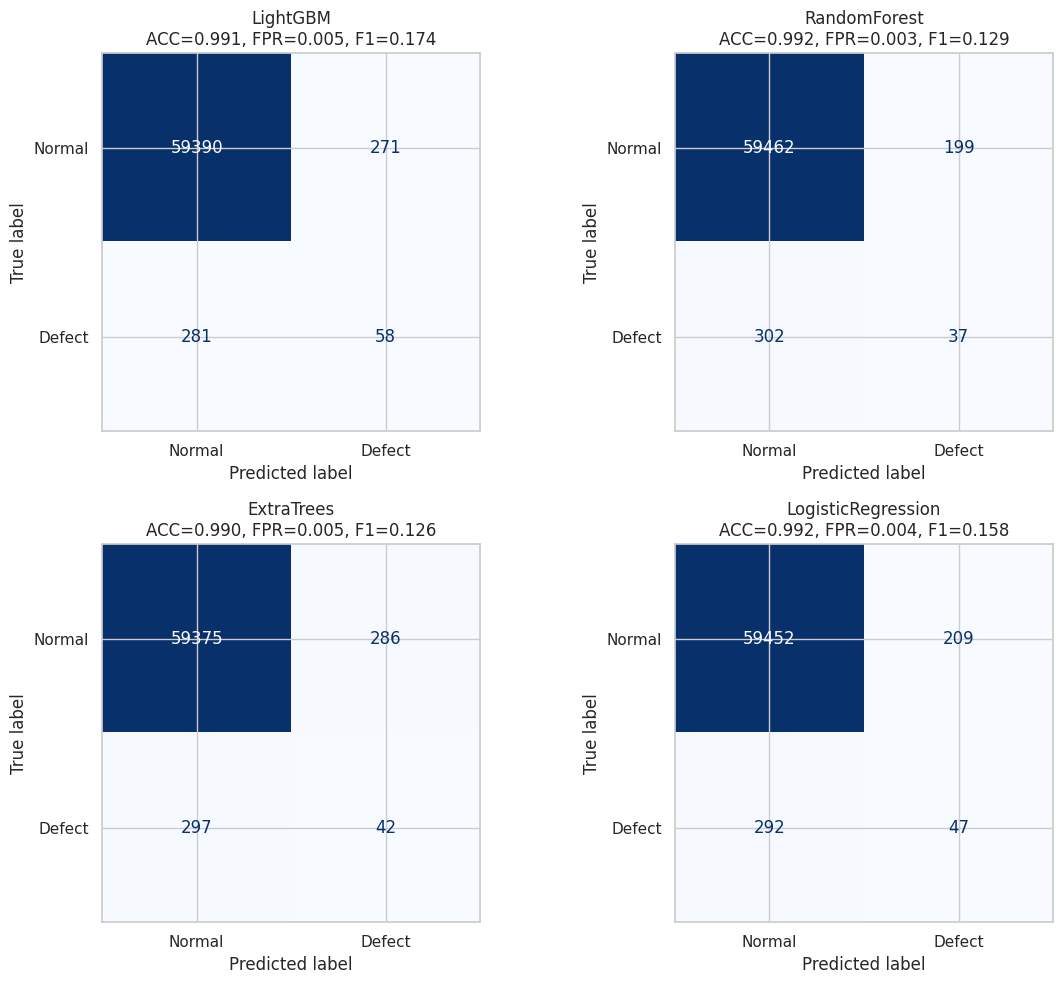

,model_name,accuracy,false_positive_rate,precision,recall,f1,roc_auc,pr_auc,threshold
0,LightGBM,0.990800,0.004542,0.176292,0.171091,0.173653,0.669980,0.054404,0.764335
1,LogisticRegression,0.991650,0.003503,0.183594,0.138643,0.157983,0.644195,0.045955,0.979877
2,RandomForest,0.991650,0.003336,0.156780,0.109145,0.128696,0.683218,0.038426,0.351859
3,ExtraTrees,0.990283,0.004794,0.128049,0.123894,0.125937,0.668943,0.034879,0.448309


In [15]:
print("== Selected Model ==")
print("model:", selected_model_name)
print("best_threshold:", round(best_threshold, 5))
print(classification_report(y_valid, valid_pred, digits=4, zero_division=0))

# 후보 모델별 Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, (model_name, cm_model) in zip(axes, model_confusion_matrices.items()):
    ConfusionMatrixDisplay(cm_model, display_labels=["Normal", "Defect"]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )
    row = model_comparison[model_comparison["model_name"].eq(model_name)].iloc[0]
    ax.set_title(
        f"{model_name}\n"
        f"ACC={row['accuracy']:.3f}, FPR={row['false_positive_rate']:.3f}, F1={row['f1']:.3f}"
    )
plt.tight_layout()
plt.show()

# 비교 지표 테이블
display(model_comparison[[
    "model_name",
    "accuracy",
    "false_positive_rate",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "threshold",
]])


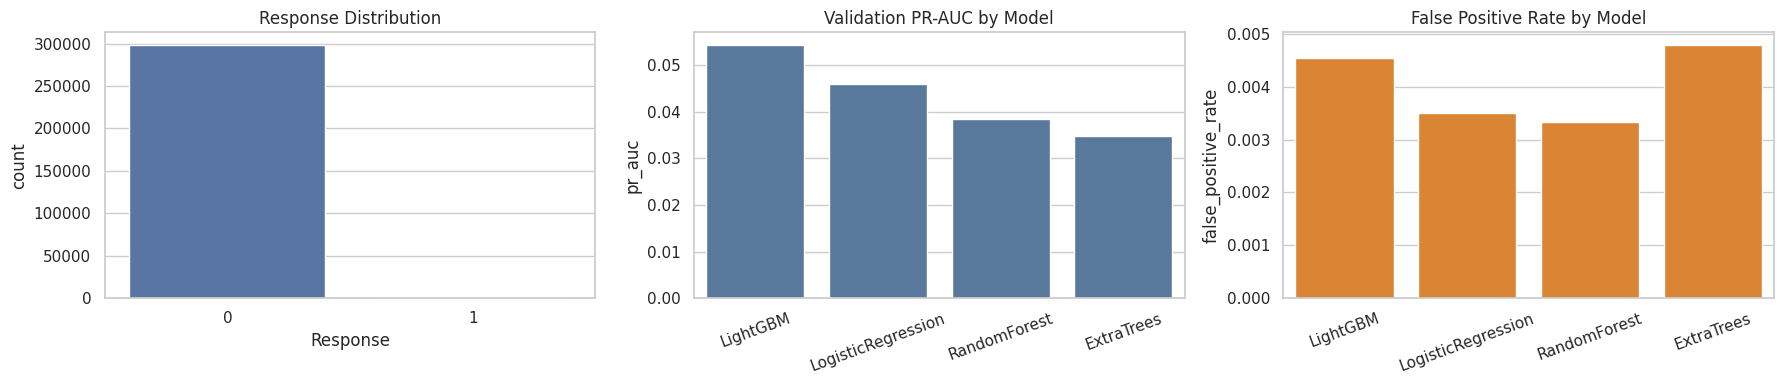

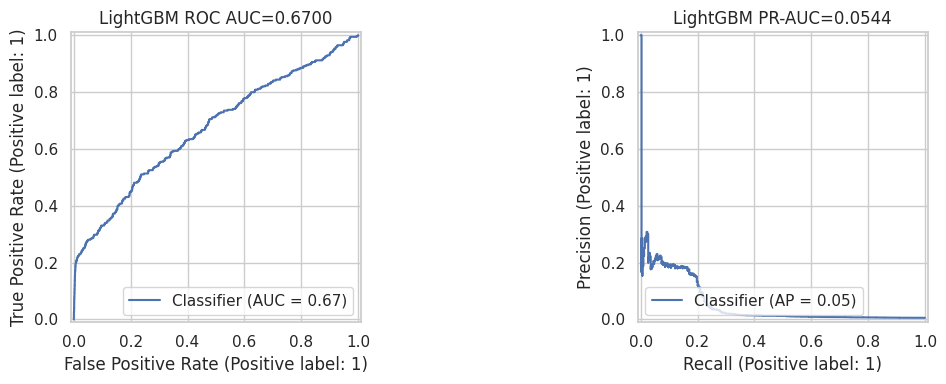

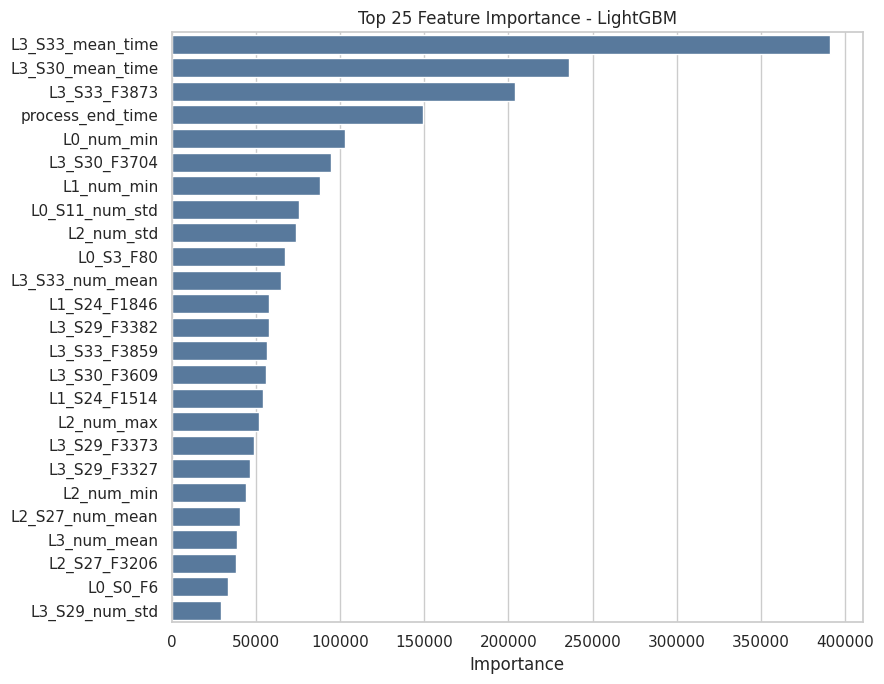

,model_name,feature,importance_gain,importance_type
0,LightGBM,L3_S33_mean_time,390956.736451,gain
1,LightGBM,L3_S30_mean_time,235859.517601,gain
2,LightGBM,L3_S33_F3873,203709.738733,gain
3,LightGBM,process_end_time,149514.344105,gain
4,LightGBM,L0_num_min,102868.559010,gain
5,LightGBM,L3_S30_F3704,94805.056677,gain
6,LightGBM,L1_num_min,87870.475541,gain
7,LightGBM,L0_S11_num_std,75906.011574,gain
8,LightGBM,L2_num_std,73896.075065,gain
9,LightGBM,L0_S3_F80,67261.653738,gain


In [16]:
# 모델 성능 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x=y, ax=axes[0])
axes[0].set_title("Response Distribution")
axes[0].set_xlabel("Response")

sns.barplot(data=model_comparison, x="model_name", y="pr_auc", ax=axes[1], color="#4C78A8")
axes[1].set_title("Validation PR-AUC by Model")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=model_comparison, x="model_name", y="false_positive_rate", ax=axes[2], color="#F58518")
axes[2].set_title("False Positive Rate by Model")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# 선택 모델 ROC/PR 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_valid, valid_proba, ax=axes[0])
axes[0].set_title(f"{selected_model_name} ROC AUC={roc_auc:.4f}")
PrecisionRecallDisplay.from_predictions(y_valid, valid_proba, ax=axes[1])
axes[1].set_title(f"{selected_model_name} PR-AUC={pr_auc:.4f}")
plt.tight_layout()
plt.show()


def extract_feature_importance(estimator, feature_names: list[str], model_name: str) -> pd.DataFrame:
    target_estimator = estimator
    if isinstance(estimator, Pipeline):
        target_estimator = estimator.named_steps.get("model", estimator)

    if hasattr(target_estimator, "booster_"):
        values = target_estimator.booster_.feature_importance(importance_type="gain")
        importance_type = "gain"
    elif hasattr(target_estimator, "feature_importances_"):
        values = target_estimator.feature_importances_
        importance_type = "feature_importances"
    elif hasattr(target_estimator, "coef_"):
        values = np.abs(target_estimator.coef_).ravel()
        importance_type = "abs_coef"
    else:
        values = np.zeros(len(feature_names))
        importance_type = "not_available"

    return pd.DataFrame({
        "model_name": model_name,
        "feature": feature_names,
        "importance": values,
        "importance_type": importance_type,
    }).sort_values("importance", ascending=False)


importance_frames = [
    extract_feature_importance(estimator, feature_cols, model_name)
    for model_name, estimator in trained_models.items()
]
all_model_importance = pd.concat(importance_frames, ignore_index=True)
importance_df = all_model_importance[all_model_importance["model_name"].eq(selected_model_name)].copy()
importance_df = importance_df.rename(columns={"importance": "importance_gain"})

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(25), y="feature", x="importance_gain", color="#4C78A8")
plt.title(f"Top 25 Feature Importance - {selected_model_name}")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(importance_df.head(30))


## 10. SHAP 기반 영향 공정 분석

선택된 최종 모델을 기준으로 SHAP 값을 계산합니다.

SHAP 값은 feature가 불량 확률 예측에 기여한 정도이며, 이후 feature를 공정 코드로 매핑해 공정별 영향도를 집계합니다.


In [17]:
# SHAP 샘플링
SHAP_SAMPLE_SIZE = min(3000, len(X_valid))
if selected_model_name == "LogisticRegression":
    SHAP_SAMPLE_SIZE = min(500, len(X_valid))

X_shap = X_valid.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
id_shap = id_valid.loc[X_shap.index]
y_shap = y_valid.loc[X_shap.index]
proba_shap = predict_positive_proba(model, X_shap)


def prepare_shap_model(estimator, X_sample: pd.DataFrame):
    if isinstance(estimator, Pipeline):
        final_estimator = estimator.named_steps["model"]
        transform_steps = estimator.steps[:-1]
        X_transformed = X_sample.copy()
        for _, step in transform_steps:
            X_transformed = step.transform(X_transformed)
        X_transformed = pd.DataFrame(X_transformed, columns=X_sample.columns, index=X_sample.index)
        return final_estimator, X_transformed
    return estimator, X_sample


shap_model, X_shap_model = prepare_shap_model(model, X_shap)

# SHAP Explainer 생성
try:
    explainer = shap.TreeExplainer(shap_model)
    raw_shap_values = explainer.shap_values(X_shap_model)
    if isinstance(raw_shap_values, list):
        shap_matrix = raw_shap_values[1]
    elif getattr(raw_shap_values, "ndim", 0) == 3:
        shap_matrix = raw_shap_values[:, :, 1]
    else:
        shap_matrix = raw_shap_values
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
except Exception:
    background = shap.sample(X_train, min(100, len(X_train)), random_state=RANDOM_STATE)
    explainer = shap.Explainer(lambda data: predict_positive_proba(model, pd.DataFrame(data, columns=X_train.columns)), background)
    raw_explanation = explainer(X_shap)
    shap_matrix = raw_explanation.values
    base_value = raw_explanation.base_values
    X_shap_model = X_shap

# SHAP 객체 구성
shap_values = shap.Explanation(
    values=shap_matrix,
    base_values=np.repeat(base_value, len(X_shap)) if np.isscalar(base_value) else base_value,
    data=X_shap.values,
    feature_names=X_shap.columns.tolist(),
)

print("selected_model_name:", selected_model_name)
print("X_shap:", X_shap.shape)
print("shap_matrix:", shap_matrix.shape)


selected_model_name: LightGBM
X_shap: (3000, 457)
shap_matrix: (3000, 457)


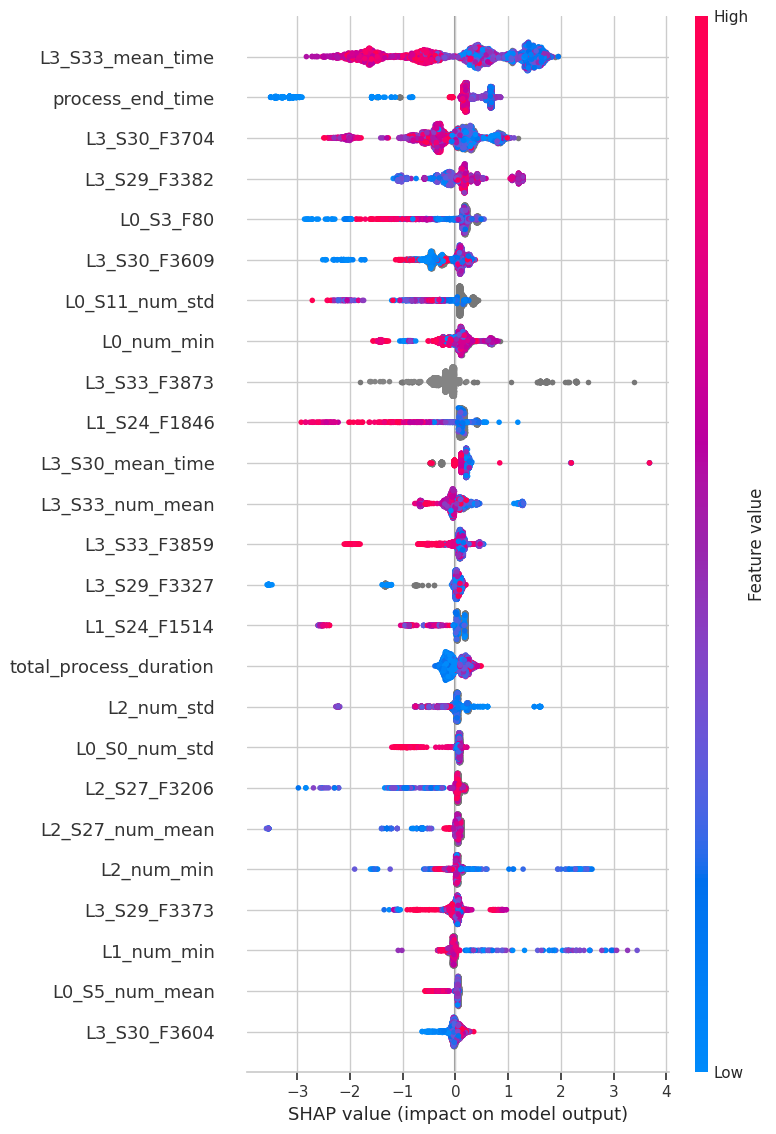

,feature,mean_abs_shap
323,L3_S33_mean_time,1.043150
263,process_end_time,0.572533
203,L3_S30_F3704,0.461738
137,L3_S29_F3382,0.329964
20,L0_S3_F80,0.312103
190,L3_S30_F3609,0.280839
370,L0_S11_num_std,0.237354
342,L0_num_min,0.236961
236,L3_S33_F3873,0.224241
94,L1_S24_F1846,0.201978


In [18]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_shap, max_display=25, show=True)

# SHAP 중요도 산출
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(30))


공정 영향도 집계 제외 전역/미매핑 feature 수: 9


,unmapped_feature
0,date_observed_count
1,date_missing_ratio
2,process_start_time
3,process_end_time
4,total_process_duration
5,max_station_span
6,mean_station_span
7,std_station_span
8,active_station_count


,process_code,mean_abs_shap,feature_count
2,PAINT,0.027860,197
3,ASSEMBLY,0.022912,36
0,PRESS,0.020474,182
1,BODY,0.019803,33


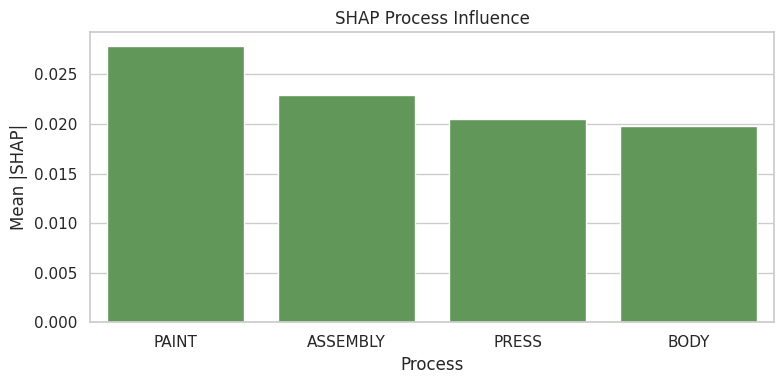

In [19]:
# Feature 공정 매핑
def feature_to_process(feature: str) -> str | None:
    """Feature 공정 매핑"""
    normalized = feature.lower()

    # Bosch 원천 컬럼/집계 컬럼: L0~L3 prefix 기준 매핑
    line = get_line(feature)
    if line in LINE_TO_PROCESS:
        return LINE_TO_PROCESS[line]

    # 보조 데이터셋 기반 feature: aux_{process}_... naming 기준 매핑
    if normalized.startswith("aux_press") or "press" in normalized:
        return "PRESS"
    if normalized.startswith("aux_body") or "body" in normalized or "robot" in normalized or "ford" in normalized:
        return "BODY"
    if normalized.startswith("aux_paint") or "paint" in normalized or "thermal" in normalized:
        return "PAINT"
    if normalized.startswith("aux_assembly") or "assembly" in normalized:
        return "ASSEMBLY"

    # 전역 feature 제외
    return None

# 후속 공정 매핑
def next_process(process_code: str) -> str:
    if process_code not in PROCESS_FLOW:
        return "FINAL_INSPECTION"
    idx = PROCESS_FLOW.index(process_code)
    if idx + 1 >= len(PROCESS_FLOW):
        return "FINAL_INSPECTION"
    return PROCESS_FLOW[idx + 1]

# 위험 등급 변환
def probability_to_risk_grade(prob: float) -> str:
    if prob >= 0.70:
        return "HIGH"
    if prob >= 0.40:
        return "MEDIUM"
    return "LOW"

# SHAP feature 공정 매핑
feature_process = pd.Series([feature_to_process(c) for c in X_shap.columns], index=X_shap.columns)
mapped_feature_mask = feature_process.isin(PROCESS_FLOW)
unmapped_features = feature_process[~mapped_feature_mask].index.tolist()
print(f"공정 영향도 집계 제외 전역/미매핑 feature 수: {len(unmapped_features)}")
if unmapped_features:
    display(pd.DataFrame({"unmapped_feature": unmapped_features}).head(30))

# 공정별 SHAP 영향도 집계
process_rows = []
for process_code in PROCESS_FLOW:
    cols_idx = np.where(feature_process.values == process_code)[0]
    process_rows.append({
        "process_code": process_code,
        "mean_abs_shap": float(np.abs(shap_matrix[:, cols_idx]).mean()) if len(cols_idx) else 0.0,
        "feature_count": int(len(cols_idx)),
    })

process_importance = pd.DataFrame(process_rows).sort_values("mean_abs_shap", ascending=False)
display(process_importance)

# 공정 영향도 시각화
plt.figure(figsize=(8, 4))
sns.barplot(data=process_importance, x="process_code", y="mean_abs_shap", color="#59A14F")
plt.title("SHAP Process Influence")
plt.xlabel("Process")
plt.ylabel("Mean |SHAP|")
plt.tight_layout()
plt.show()


## 11. SHAP 기반 전이 위험 결과 생성

아래 결과는 PRD의 `defect_transfer_prediction_result` 저장 구조에 맞춘 예측 테이블입니다.


In [20]:
# 전이 위험 결과 생성
def build_transfer_predictions(
    ids: pd.Series,
    probabilities: np.ndarray,
    shap_matrix: np.ndarray,
    feature_names: list[str],
    feature_process: pd.Series,
) -> pd.DataFrame:
    records = []
    process_values = feature_process.values
    predicted_at = datetime.now(timezone.utc).isoformat()

    # 샘플별 공정 영향도 계산
    for row_idx, (sample_id, prob) in enumerate(zip(ids.to_numpy(), probabilities)):
        abs_values = np.abs(shap_matrix[row_idx])
        mapped_mask = feature_process.isin(PROCESS_FLOW).to_numpy()
        mapped_abs_values = abs_values[mapped_mask]
        mapped_process_values = process_values[mapped_mask]
        total_abs = float(mapped_abs_values.sum()) or 1.0

        # 공정별 영향 비율
        process_scores = {}
        for process_code in PROCESS_FLOW:
            col_idx = np.where(mapped_process_values == process_code)[0]
            process_scores[process_code] = float(mapped_abs_values[col_idx].sum() / total_abs) if len(col_idx) else 0.0

        # 원인/대상 공정 산출
        source_process = max(process_scores, key=process_scores.get)
        target_process = next_process(source_process)
        source_col_idx = np.where(process_values == source_process)[0]
        top_feature_idx = int(source_col_idx[np.argmax(abs_values[source_col_idx])]) if len(source_col_idx) else int(abs_values.argmax())
        influence_score = process_scores[source_process]

        records.append({
            "car_master_id": int(sample_id),
            "source_process_code": source_process,
            "target_process_code": target_process,
            "current_defect_probability": round(float(influence_score), 6),
            "target_defect_probability": round(float(prob), 6),
            "predicted_defect_process": target_process,
            "risk_grade": probability_to_risk_grade(float(prob)),
            "main_cause": feature_names[top_feature_idx],
            "influence_score": round(float(influence_score), 6),
            "predicted_at": predicted_at,
        })
    return pd.DataFrame(records).sort_values(["target_defect_probability", "influence_score"], ascending=False)

# 전이 예측 테이블 생성
transfer_predictions = build_transfer_predictions(
    id_shap,
    proba_shap,
    shap_matrix,
    X_shap.columns.tolist(),
    feature_process,
)

display(transfer_predictions.head(30))

# 전이 위험 요약
risk_summary = transfer_predictions.groupby(["source_process_code", "target_process_code", "risk_grade"]).agg(
    vehicle_count=("car_master_id", "count"),
    avg_target_defect_probability=("target_defect_probability", "mean"),
    avg_influence_score=("influence_score", "mean"),
).reset_index().sort_values(["avg_target_defect_probability", "vehicle_count"], ascending=False)
display(risk_summary)


,car_master_id,source_process_code,target_process_code,current_defect_probability,target_defect_probability,predicted_defect_process,risk_grade,main_cause,influence_score,predicted_at
2806,218707,PAINT,ASSEMBLY,0.678618,0.978448,ASSEMBLY,HIGH,L3_S30_mean_time,0.678618,2026-06-12T08:00:21.829407+00:00
1720,327784,PAINT,ASSEMBLY,0.693589,0.970204,ASSEMBLY,HIGH,L3_S30_mean_time,0.693589,2026-06-12T08:00:21.829407+00:00
2920,110780,PAINT,ASSEMBLY,0.677194,0.937242,ASSEMBLY,HIGH,L3_S33_F3873,0.677194,2026-06-12T08:00:21.829407+00:00
1676,404144,PAINT,ASSEMBLY,0.577193,0.909687,ASSEMBLY,HIGH,L3_S33_mean_time,0.577193,2026-06-12T08:00:21.829407+00:00
518,537209,ASSEMBLY,FINAL_INSPECTION,0.442684,0.855171,FINAL_INSPECTION,HIGH,L2_num_min,0.442684,2026-06-12T08:00:21.829407+00:00
1363,422924,PAINT,ASSEMBLY,0.461277,0.829406,ASSEMBLY,HIGH,L3_S33_mean_time,0.461277,2026-06-12T08:00:21.829407+00:00
22,445099,PAINT,ASSEMBLY,0.437623,0.826252,ASSEMBLY,HIGH,L3_S33_mean_time,0.437623,2026-06-12T08:00:21.829407+00:00
883,49121,PAINT,ASSEMBLY,0.647237,0.810856,ASSEMBLY,HIGH,L3_S33_F3873,0.647237,2026-06-12T08:00:21.829407+00:00
1139,270422,BODY,PAINT,0.380287,0.806972,PAINT,HIGH,L1_num_min,0.380287,2026-06-12T08:00:21.829407+00:00
1261,72604,PAINT,ASSEMBLY,0.576640,0.802120,ASSEMBLY,HIGH,L3_S33_mean_time,0.576640,2026-06-12T08:00:21.829407+00:00


,source_process_code,target_process_code,risk_grade,vehicle_count,avg_target_defect_probability,avg_influence_score
5,PAINT,ASSEMBLY,HIGH,10,0.857837,0.581562
0,ASSEMBLY,FINAL_INSPECTION,HIGH,1,0.855171,0.442684
3,BODY,PAINT,HIGH,1,0.806972,0.380287
7,PAINT,ASSEMBLY,MEDIUM,78,0.487962,0.569717
9,PRESS,BODY,MEDIUM,1,0.480493,0.454110
2,ASSEMBLY,FINAL_INSPECTION,MEDIUM,5,0.471322,0.421606
1,ASSEMBLY,FINAL_INSPECTION,LOW,49,0.097117,0.398196
4,BODY,PAINT,LOW,54,0.080397,0.411830
6,PAINT,ASSEMBLY,LOW,2462,0.066433,0.533395
8,PRESS,BODY,LOW,339,0.014134,0.497065


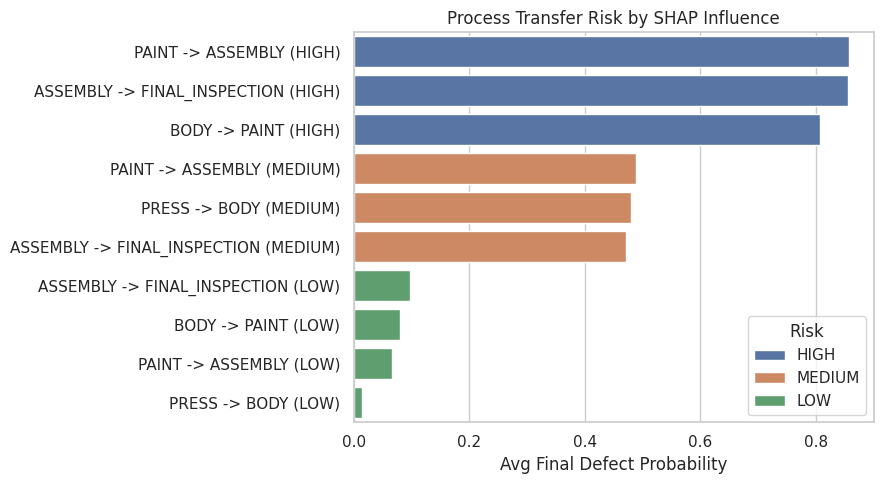

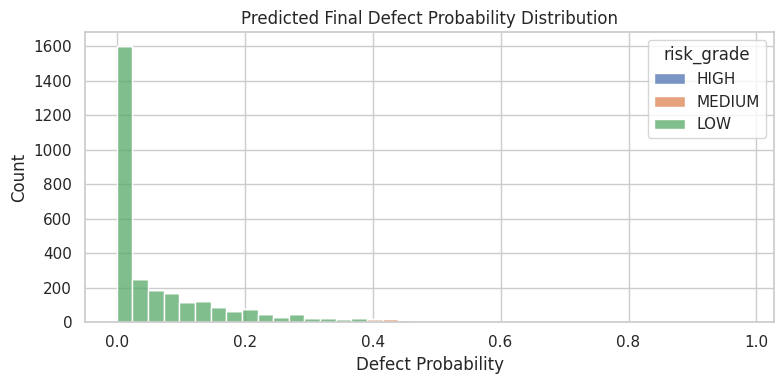

In [21]:
# 전이 위험 시각화
plt.figure(figsize=(9, 5))
top_flow = risk_summary.head(12).copy()
top_flow["flow"] = top_flow["source_process_code"] + " -> " + top_flow["target_process_code"] + " (" + top_flow["risk_grade"] + ")"
sns.barplot(data=top_flow, y="flow", x="avg_target_defect_probability", hue="risk_grade", dodge=False)
plt.title("Process Transfer Risk by SHAP Influence")
plt.xlabel("Avg Final Defect Probability")
plt.ylabel("")
plt.legend(title="Risk")
plt.tight_layout()
plt.show()

# 불량 확률 분포 시각화
plt.figure(figsize=(8, 4))
sns.histplot(data=transfer_predictions, x="target_defect_probability", hue="risk_grade", bins=40, multiple="stack")
plt.title("Predicted Final Defect Probability Distribution")
plt.xlabel("Defect Probability")
plt.tight_layout()
plt.show()


## 12. AI 모델 관리 항목

모델 선정 근거, 데이터셋 규모, 테스트 케이스 수, Accuracy, False Positive Rate, 성능 개선 현황을 운영 관리용 요약으로 정리합니다.


In [22]:
ai_management_table = pd.DataFrame([
    {"관리 항목": "모델 선정 근거 정리", "값": ai_management_summary["모델_선정_근거"]},
    {"관리 항목": "데이터셋 규모 관리", "값": json.dumps(ai_management_summary["데이터셋_규모_관리"], ensure_ascii=False)},
    {"관리 항목": "테스트 케이스 수 관리", "값": json.dumps(ai_management_summary["테스트_케이스_수_관리"], ensure_ascii=False)},
    {"관리 항목": "정확도(Accuracy) 측정", "값": round(ai_management_summary["정확도_Accuracy"], 6)},
    {"관리 항목": "오탐률(False Positive Rate) 측정", "값": round(ai_management_summary["오탐률_False_Positive_Rate"], 6)},
    {"관리 항목": "모델 성능 개선 현황 관리", "값": json.dumps(ai_management_summary["모델_성능_개선_현황"], ensure_ascii=False)},
])

display(ai_management_table)


,관리 항목,값
0,모델 선정 근거 정리,LightGBM 모델이 validation PR-AUC/ROC-AUC/F1 기준 종...
1,데이터셋 규모 관리,"{""max_rows"": 300000, ""profile_rows"": 50000, ""t..."
2,테스트 케이스 수 관리,"{""validation_total"": 60000, ""validation_normal..."
3,정확도(Accuracy) 측정,0.9908
4,오탐률(False Positive Rate) 측정,0.004542
5,모델 성능 개선 현황 관리,"{""baseline_model"": ""LightGBM"", ""baseline_pr_au..."


## 13. 모델 및 결과 저장


In [23]:
# 저장 경로
selected_model_path = OUTPUT_DIR / "selected_defect_detector.joblib"
selected_model_pkl_path = OUTPUT_DIR / "selected_defect_detector.pkl"
candidate_models_path = OUTPUT_DIR / "candidate_defect_models.joblib"
candidate_models_pkl_path = OUTPUT_DIR / "candidate_defect_models.pkl"
model_path = OUTPUT_DIR / "lightgbm_defect_detector.joblib"
model_pkl_path = OUTPUT_DIR / "lightgbm_defect_detector.pkl"
aux_model_path = OUTPUT_DIR / "auxiliary_process_models.joblib"
aux_model_pkl_path = OUTPUT_DIR / "auxiliary_process_models.pkl"
feature_path = OUTPUT_DIR / "defect_model_features.json"
metrics_path = OUTPUT_DIR / "defect_model_metrics.json"
comparison_path = OUTPUT_DIR / "defect_model_comparison.csv"
confusion_matrix_path = OUTPUT_DIR / "defect_model_confusion_matrices.json"
ai_management_path = OUTPUT_DIR / "defect_ai_management_summary.json"
importance_path = OUTPUT_DIR / "defect_model_feature_importance.csv"
all_importance_path = OUTPUT_DIR / "defect_all_model_feature_importance.csv"
shap_importance_path = OUTPUT_DIR / "defect_shap_importance.csv"
transfer_path = OUTPUT_DIR / "defect_transfer_prediction_result.csv"
risk_summary_path = OUTPUT_DIR / "defect_transfer_risk_summary.csv"

# 모델 저장
joblib.dump(model, selected_model_path)
joblib.dump(trained_models, candidate_models_path)
joblib.dump(auxiliary_models, aux_model_path)
with open(selected_model_pkl_path, "wb") as f:
    pickle.dump(model, f)
with open(candidate_models_pkl_path, "wb") as f:
    pickle.dump(trained_models, f)
with open(aux_model_pkl_path, "wb") as f:
    pickle.dump(auxiliary_models, f)

# 기존 LightGBM 파일명 호환 저장
if "LightGBM" in trained_models:
    joblib.dump(trained_models["LightGBM"], model_path)
    with open(model_pkl_path, "wb") as f:
        pickle.dump(trained_models["LightGBM"], f)

feature_path.write_text(json.dumps(feature_cols, ensure_ascii=False, indent=2), encoding="utf-8")

confusion_payload = {
    name: matrix.tolist()
    for name, matrix in model_confusion_matrices.items()
}
confusion_matrix_path.write_text(json.dumps(confusion_payload, ensure_ascii=False, indent=2), encoding="utf-8")
ai_management_path.write_text(json.dumps(ai_management_summary, ensure_ascii=False, indent=2), encoding="utf-8")

# 평가 지표 저장
metrics = {
    "selected_model_name": selected_model_name,
    "roc_auc": float(roc_auc),
    "average_precision": float(pr_auc),
    "accuracy": float(accuracy),
    "false_positive_rate": float(false_positive_rate),
    "best_threshold": float(best_threshold),
    "f1_at_best_threshold": float(f1_score(y_valid, valid_pred, zero_division=0)),
    "confusion_matrix": cm.tolist(),
    "train_rows": int(len(X_train)),
    "valid_rows": int(len(X_valid)),
    "feature_count": int(len(feature_cols)),
    "positive_ratio_train": float(y_train.mean()),
    "candidate_models": list(trained_models.keys()),
    "model_selection_reason": ai_management_summary["모델_선정_근거"],
    "auxiliary_metrics": auxiliary_metrics,
    "auxiliary_feature_columns": [c for c in feature_cols if c.startswith("aux_")],
    "created_at": datetime.now(timezone.utc).isoformat(),
}
metrics_path.write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")

# 분석 결과 저장
cv_results.to_csv(cv_results_path, index=False)
model_comparison.to_csv(comparison_path, index=False)
importance_df.to_csv(importance_path, index=False)
all_model_importance.to_csv(all_importance_path, index=False)
shap_importance.to_csv(shap_importance_path, index=False)
transfer_predictions.to_csv(transfer_path, index=False)
risk_summary.to_csv(risk_summary_path, index=False)

print("Saved outputs:")
for path in [
    selected_model_path,
    selected_model_pkl_path,
    candidate_models_path,
    candidate_models_pkl_path,
    model_path,
    model_pkl_path,
    aux_model_path,
    aux_model_pkl_path,
    feature_path,
    metrics_path,
    cv_results_path,
    comparison_path,
    confusion_matrix_path,
    ai_management_path,
    importance_path,
    all_importance_path,
    shap_importance_path,
    transfer_path,
    risk_summary_path,
]:
    print(path)


Saved outputs:
/content/defect_transfer_outputs/selected_defect_detector.joblib
/content/defect_transfer_outputs/selected_defect_detector.pkl
/content/defect_transfer_outputs/candidate_defect_models.joblib
/content/defect_transfer_outputs/candidate_defect_models.pkl
/content/defect_transfer_outputs/lightgbm_defect_detector.joblib
/content/defect_transfer_outputs/lightgbm_defect_detector.pkl
/content/defect_transfer_outputs/auxiliary_process_models.joblib
/content/defect_transfer_outputs/auxiliary_process_models.pkl
/content/defect_transfer_outputs/defect_model_features.json
/content/defect_transfer_outputs/defect_model_metrics.json
/content/defect_transfer_outputs/defect_model_cv_results.csv
/content/defect_transfer_outputs/defect_model_comparison.csv
/content/defect_transfer_outputs/defect_model_confusion_matrices.json
/content/defect_transfer_outputs/defect_ai_management_summary.json
/content/defect_transfer_outputs/defect_model_feature_importance.csv
/content/defect_transfer_outputs